In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
#Directorio para que encuentre las demas clases
%cd "/content/drive/MyDrive/Colab Notebooks/ProyectoFin/"

/content/drive/MyDrive/Colab Notebooks/ProyectoFin


In [21]:
#celda necesaria para coneccion con mysql
!pip install mysql-connector-python

**Importacion de las clases**

In [22]:
from gestorDB import gestorDB
from preprocesador import preprocesador

**Instancias de las clases**

In [23]:
db = gestorDB()
pre = preprocesador("/content/drive/MyDrive/Colab Notebooks/ProyectoFin/cardio_train.csv")


**Carga de datos desde BD**

In [24]:
#df_completo = db.obtener_datos("dataset_completo")

**Pasar al preprocesador**

In [25]:
# Inicializamos el objeto apuntando al archivo CSV de Drive
pre = preprocesador("/content/drive/MyDrive/Colab Notebooks/ProyectoFin/cardio_train.csv")

# EN LUGAR DE USAR BASE DE DATOS, LLAMAMOS AL MÉTODO DEL CSV:
pre.cargar_CSV()

# Ahora sí, podemos limpiar con seguridad
pre.limpiar_datos()

Datos cargados correctamente
Forma del dataset: (70000, 12)
Los registros despues de filtrar por ap: (68649, 12)
Los registros despues de filtrar por peso y altura: (68489, 13)
Registros eliminados: 1511


A Por porcentaje

In [26]:
# Un error del 5% generará una muestra significativamente más pequeña y ligera
df_muestra = pre.muestrear_datos(margen_error=0.05)


 Muestreo Estadístico (95% Confianza / 5.0% Error):
-> Muestra representativa generada: 382 registros.


##MODELOS

importar modelos

In [27]:
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from evaluador_modelos import EvaluadorModelos

print("módulos importados.")

módulos importados.


Carga de datos y splits

In [28]:
# 4. Extraemos tu muestra controlada (30%) usando train_test_split
from sklearn.model_selection import train_test_split
df_limpio = pre.df_limpio  # Tomamos los datos limpios que generó tu clase

df_reducido, _ = train_test_split(
    df_limpio,
    train_size=0.30,
    random_state=42,
    stratify=df_limpio['cardio']
)

# 5. Llamamos a tu método corregido que regresa los datos en bruto
x_train, y_train, x_val, y_val, x_test, y_test = pre.transformar_datos(df_reducido)

# 6. Inicializamos el evaluador pasándole el objeto 'pre' para que extraiga el ColumnTransformer
evaluador = EvaluadorModelos(pre)

print(f"\n x_train listo en bruto con: {x_train.shape}")


 x_train listo en bruto con: (12327, 10)


##Tabla de comparacion

In [29]:
# Mandamos a llamar la evaluación cruzada que guardamos en el archivo .py
df_resultados = evaluador.evaluar_validacion_cruzada(x_train, y_train)

# Pintamos la tabla bonita en el cuaderno
df_resultados.style.highlight_max(subset=['Exactitud Promedio (Accuracy)'], color='lightgreen').format({
    'Exactitud Promedio (Accuracy)': '{:.4f}',
    'Variabilidad (Std)': '{:.4f}'
})

,Modelo,Exactitud Promedio (Accuracy),Variabilidad (Std)
0,Random Forest,0.7330,0.0033
1,Regresión Logística,0.7282,0.0044
2,Árbol de Decisión,0.7070,0.0099
3,Naive Bayes,0.6922,0.0028
4,k-NN,0.6906,0.0046


Gráficas de Resultados Individuales (Matriz de Confusión y Reporte)

==================== REPORTE DETALLADO: Naive Bayes ====================
              precision    recall  f1-score   support

    Sano (0)       0.67      0.82      0.74      2076
 Enfermo (1)       0.76      0.59      0.66      2033

    accuracy                           0.70      4109
   macro avg       0.71      0.70      0.70      4109
weighted avg       0.71      0.70      0.70      4109



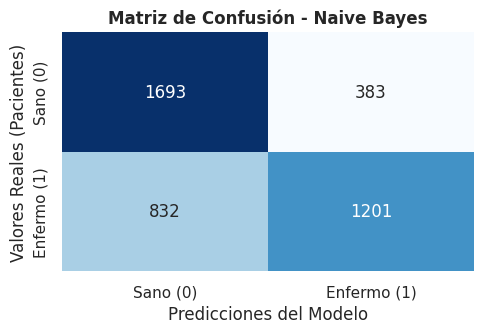

In [30]:
# 1. Definimos la variable exacta que va a leer la función
modelo_a_revisar = "Naive Bayes"

# 2. Llamamos al evaluador con los nombres de variables correctos
preds, probs, reporte, cm = evaluador.obtener_predicciones_y_metricas(
    modelo_a_revisar, x_train, y_train, x_val, y_val
)

# 3. Imprimimos el reporte médico completo
print(f"==================== REPORTE DETALLADO: {modelo_a_revisar} ====================")
print(reporte)

# 4. Graficamos la Matriz de Confusión corregida
plt.figure(figsize=(5, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Sano (0)', 'Enfermo (1)'],
            yticklabels=['Sano (0)', 'Enfermo (1)'])

plt.xlabel('Predicciones del Modelo')
plt.ylabel('Valores Reales (Pacientes)')
plt.title(f'Matriz de Confusión - {modelo_a_revisar}', fontweight='bold')
plt.tight_layout()
plt.show()

Curva ROC

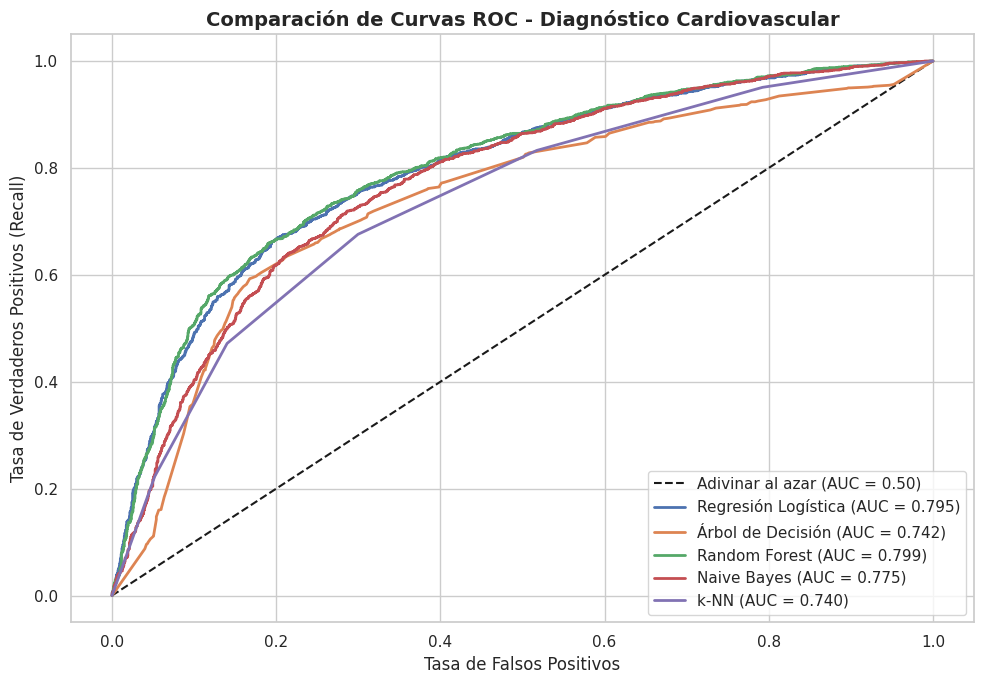

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Adivinar al azar (AUC = 0.50)')

# Recuperamos la estructura interna de los modelos
for nombre, pipeline in evaluador.obtener_todos_los_modelos().items():

    # Entrenamos formalmente el pipeline completo antes de pedirle predicciones
    pipeline.fit(x_train, y_train)

    # Ahora que ya estudió, le pedimos sus probabilidades de forma segura
    if hasattr(pipeline.named_steps['mod'], "predict_proba"):
        probabilidades = pipeline.predict_proba(x_val)[:, 1]
    else:
        probabilidades = pipeline.decision_function(x_val)

    # Calculamos las métricas de la curva
    fpr, tpr, _ = roc_curve(y_val, probabilidades)
    auc_score = roc_auc_score(y_val, probabilidades)

    # Graficamos la línea de este modelo
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc_score:.3f})', linewidth=2)

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Comparación de Curvas ROC - Diagnóstico Cardiovascular', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()